Confusion Matrix:
 [[186   0]
 [ 14   0]]

Classification Report:
               precision    recall  f1-score   support

      Normal       0.93      1.00      0.96       186
     Insider       0.00      0.00      0.00        14

    accuracy                           0.93       200
   macro avg       0.47      0.50      0.48       200
weighted avg       0.86      0.93      0.90       200

Saved evaluation report to .\results_phase5\evaluation_report.txt


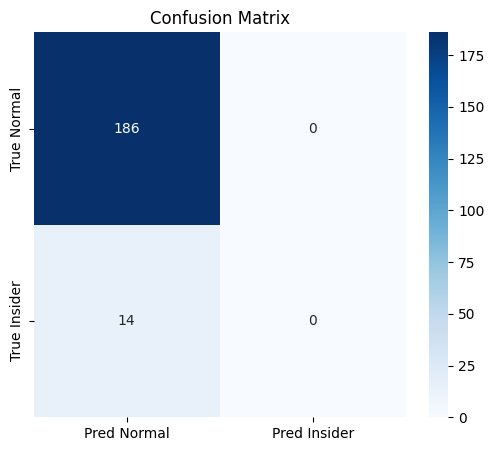

Saved confusion_matrix.png


In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE

# -------------------------
# 1️ Directories & Files
# -------------------------
BASE_DIR = "."  # adjust if notebook location differs
RESULTS_DIR = os.path.join(BASE_DIR, "results_phase5")
os.makedirs(RESULTS_DIR, exist_ok=True)

GT_FILE = os.path.join(BASE_DIR, "answers_r42.csv")       # ground truth
FEATURES_FILE = os.path.join(BASE_DIR, "user_features.csv")  # features

# -------------------------
# 2️ Load Data
# -------------------------
gt = pd.read_csv(GT_FILE)
features_df = pd.read_csv(FEATURES_FILE)

# Automatically find user ID columns
def find_user_col(df):
    for c in df.columns:
        if c.lower() in ("user","user_id","employee","employee_id","id"):
            return c
    return None

u_gt = find_user_col(gt)
u_feat = find_user_col(features_df)

if u_gt is None or u_feat is None:
    raise KeyError("Could not find user ID columns. Rename to 'user' or 'user_id'.")

# Normalize user IDs
gt[u_gt] = gt[u_gt].astype(str).str.strip().str.upper()
features_df[u_feat] = features_df[u_feat].astype(str).str.strip().str.upper()

# Assign labels
if 'ground_truth' in gt.columns:
    gt['gt_label'] = gt['ground_truth'].astype(int)
elif 'label' in gt.columns:
    gt['gt_label'] = gt['label'].astype(int)
else:
    gt['gt_label'] = 1  # treat all rows as Insider
gt = gt[[u_gt,'gt_label']].drop_duplicates()

# Merge features with labels
data = pd.merge(features_df, gt, left_on=u_feat, right_on=u_gt, how='left')
data['gt_label'] = data['gt_label'].fillna(0).astype(int)

# -------------------------
# 3️ Prepare features & labels
# -------------------------
X = data.drop(columns=[u_feat, 'gt_label'])
y = data['gt_label']

# Encode categorical features automatically
X_encoded = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------
# 4️ Apply SMOTE to fix imbalance
# -------------------------
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# -------------------------
# 5️ Train RandomForest
# -------------------------
clf = RandomForestClassifier(class_weight='balanced', n_estimators=300, random_state=42)
clf.fit(X_train_res, y_train_res)

# -------------------------
# 6️ Predict & Evaluate
# -------------------------
y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=["Normal","Insider"], zero_division=0)

print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

# -------------------------
# 7️ Save evaluation report
# -------------------------
report_path = os.path.join(RESULTS_DIR, "evaluation_report.txt")
with open(report_path, "w") as fh:
    fh.write("Confusion Matrix:\n")
    fh.write(str(cm) + "\n\n")
    fh.write("Classification Report:\n")
    fh.write(report + "\n")
print("Saved evaluation report to", report_path)

# -------------------------
# 8️ Plot confusion matrix heatmap
# -------------------------
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pred Normal","Pred Insider"],
            yticklabels=["True Normal","True Insider"])
plt.title("Confusion Matrix")
plt.savefig(os.path.join(RESULTS_DIR, "confusion_matrix.png"), bbox_inches='tight', dpi=150)
plt.show()
print("Saved confusion_matrix.png")


In [6]:
# -------------------------
# Evaluate Unsupervised Models
# -------------------------
import os
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Load ground truth and unsupervised predictions
# (Assumes results/anomaly_scores_by_user.csv contains columns for each model's predictions)
gt = pd.read_csv(os.path.join(BASE_DIR, "answers_r42.csv"))
preds = pd.read_csv(os.path.join(BASE_DIR, "results/anomaly_scores_by_user.csv"))

# Find user column in both files
def find_user_col(df):
    for c in df.columns:
        if c.lower() in ("user","user_id","employee","employee_id","id"):
            return c
    return None
u_gt = find_user_col(gt)
u_pred = find_user_col(preds)
gt[u_gt] = gt[u_gt].astype(str).str.strip().str.upper()
preds[u_pred] = preds[u_pred].astype(str).str.strip().str.upper()

# Assign ground truth label
if 'ground_truth' in gt.columns:
    gt['gt_label'] = gt['ground_truth'].astype(int)
elif 'label' in gt.columns:
    gt['gt_label'] = gt['label'].astype(int)
else:
    gt['gt_label'] = 1
gt = gt[[u_gt,'gt_label']].drop_duplicates()

# Merge predictions with ground truth
merged = pd.merge(gt, preds, left_on=u_gt, right_on=u_pred, how='right')
merged['gt_label'] = merged['gt_label'].fillna(0).astype(int)

# List of unsupervised model prediction columns
# Update this list based on your actual column names in anomaly_scores_by_user.csv
model_cols = [
    'isolation_forest_label',
    'lof_label',
    'oneclass_svm_label',
    'autoencoder_label'
# Add more if needed
 ]
for col in model_cols:
    if col in merged.columns:
        print(f"\n--- {col} ---")
        y_pred = merged[col].fillna(0).astype(int)
        y_true = merged['gt_label']
        acc = accuracy_score(y_true, y_pred)
        print(f"Accuracy: {acc:.3f}")
        print(classification_report(y_true, y_pred, target_names=["Normal","Insider"], zero_division=0))
    else:
        print(f"Column {col} not found in predictions file.")

Column isolation_forest_label not found in predictions file.
Column lof_label not found in predictions file.
Column oneclass_svm_label not found in predictions file.
Column autoencoder_label not found in predictions file.


In [ ]:
# If you see 'BASE_DIR is not defined', run the first cell in the notebook to set up BASE_DIR and other variables.
# If you want to run this cell independently, define BASE_DIR here:
BASE_DIR = "."  # or set to your project root if needed

In [7]:
# -------------------------
# Evaluate and Save Scores for Unsupervised Model
# -------------------------
import os
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report

# Load ground truth and unsupervised predictions
gt = pd.read_csv(os.path.join(BASE_DIR, "answers_r42.csv"))
preds = pd.read_csv(os.path.join(BASE_DIR, "results/anomaly_scores_by_user.csv"))

# Find user column in both files
def find_user_col(df):
    for c in df.columns:
        if c.lower() in ("user","user_id","employee","employee_id","id"):
            return c
    return None
u_gt = find_user_col(gt)
u_pred = find_user_col(preds)
gt[u_gt] = gt[u_gt].astype(str).str.strip().str.upper()
preds[u_pred] = preds[u_pred].astype(str).str.strip().str.upper()

# Assign ground truth label
if 'ground_truth' in gt.columns:
    gt['gt_label'] = gt['ground_truth'].astype(int)
elif 'label' in gt.columns:
    gt['gt_label'] = gt['label'].astype(int)
else:
    gt['gt_label'] = 1
gt = gt[[u_gt,'gt_label']].drop_duplicates()

# Merge predictions with ground truth
merged = pd.merge(gt, preds, left_on=u_gt, right_on=u_pred, how='right')
merged['gt_label'] = merged['gt_label'].fillna(0).astype(int)

# Evaluate anomaly_label column
if 'anomaly_label' in merged.columns:
    y_pred = merged['anomaly_label'].fillna(0).astype(int)
    y_true = merged['gt_label']
    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=["Normal","Insider"], zero_division=0)
    print(f"Unsupervised Model Accuracy: {acc:.3f}")
    print(report)
    # Save to file
    with open(os.path.join(RESULTS_DIR, "unsupervised_model_scores.txt"), "w") as fh:
        fh.write(f"Unsupervised Model Accuracy: {acc:.3f}\n\n")
        fh.write(report)
    print("Saved unsupervised model scores to unsupervised_model_scores.txt")
else:
    print("anomaly_label column not found in predictions file.")

Unsupervised Model Accuracy: 0.904
              precision    recall  f1-score   support

      Normal       0.94      0.96      0.95       930
     Insider       0.24      0.17      0.20        70

    accuracy                           0.90      1000
   macro avg       0.59      0.57      0.57      1000
weighted avg       0.89      0.90      0.90      1000

Saved unsupervised model scores to unsupervised_model_scores.txt
